In [149]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

In [150]:
conn = sqlite3.connect('movies_database.db')

In [151]:
cursor = conn.cursor()

In [152]:
def query_graph(query, cursor, title="Movie Data Analysis", xlabel="Category", ylabel="Values"):
    cursor.execute(query)
    rows = cursor.fetchall()
    
    if not rows:
        print(f"No data for: {title}")
        return

    # Extract X and Y data
    # We take the first column for X and the last column for Y (usually the count/sum)
    x_data = [str(row[0]) for row in rows]
    y_data = [row[-1] for row in rows]

    # Increase overall figure size for clarity
    plt.figure(figsize=(14, 7))
    
    # Use a slightly thinner bar (width=0.6) to create space between columns
    bars = plt.bar(x_data, y_data, color='#3498db', edgecolor='#2980b9', width=0.6)

    # Increase font sizes for readability
    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.xlabel(xlabel, fontsize=14, fontweight='semibold')
    plt.ylabel(ylabel, fontsize=14, fontweight='semibold')

    step = 1
    if len(x_data) > 20:
        step = 2
    if len(x_data) > 40:
        step = 5

    # Handle X-axis labels to avoid overlap
    rotation = 90 if len(x_data) > 10 else 45
    plt.xticks(range(0, len(x_data), step), x_data[::step], rotation=rotation, ha='right', fontsize=11)
    plt.yticks(fontsize=11)

    # Add a subtle grid
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Auto-adjust layout so nothing is cut off
    plt.tight_layout()
    plt.show()

In [153]:
def plot_genre_evolution(query, cursor):
    # Φόρτωση δεδομένων σε DataFrame
    df = pd.read_sql_query(query, conn)
    
    # Conversion of the year into a number
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df.dropna(subset=['year'])
    df['year'] = df['year'].astype(int)

    # Keep the last 25 years.
    current_year = df['year'].max()
    df = df[df['year'] > (current_year - 25)]

    # Finding the Top 5 Genres based on the total number of movies
    top_genres = df.groupby('genre')['movies_count'].sum().nlargest(5).index
    df_top = df[df['genre'].isin(top_genres)]

    # x-axis: years, y-axis: species
    pivot_df = df_top.pivot(index='year', columns='genre', values='movies_count').fillna(0)

    # figure
    plt.figure(figsize=(15, 8))
    pivot_df.plot(kind='line', marker='o', ax=plt.gca(), linewidth=2, markersize=4)

    # fonts
    plt.title("Evolution of Top 5 Movie Genres (Last 25 Years)", fontsize=18, fontweight='bold', pad=20)
    plt.xlabel("Year", fontsize=14, fontweight='semibold')
    plt.ylabel("Movies per Year", fontsize=14, fontweight='semibold')
    
    plt.legend(title="Genres", fontsize=12, title_fontsize=13)
    plt.xticks(pivot_df.index, rotation=45, fontsize=10)
    plt.yticks(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

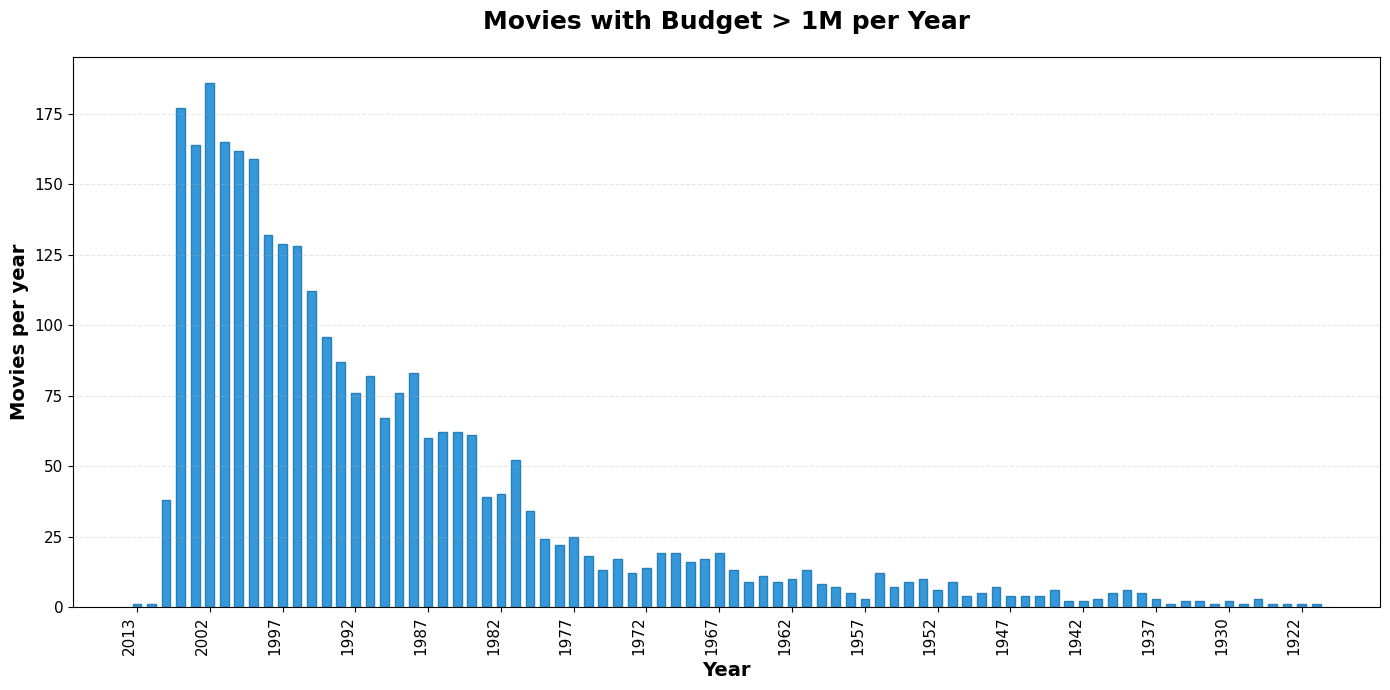

In [154]:
query1 = """
SELECT 
    strftime('%Y', release_date) AS year, 
    COUNT(*) AS movies_per_year
FROM movie
WHERE budget > 1000000 
  AND release_date IS NOT NULL
GROUP BY year
ORDER BY year DESC;
"""
query_graph(query1, cursor, "Movies with Budget > 1M per Year", "Year", "Movies per year")

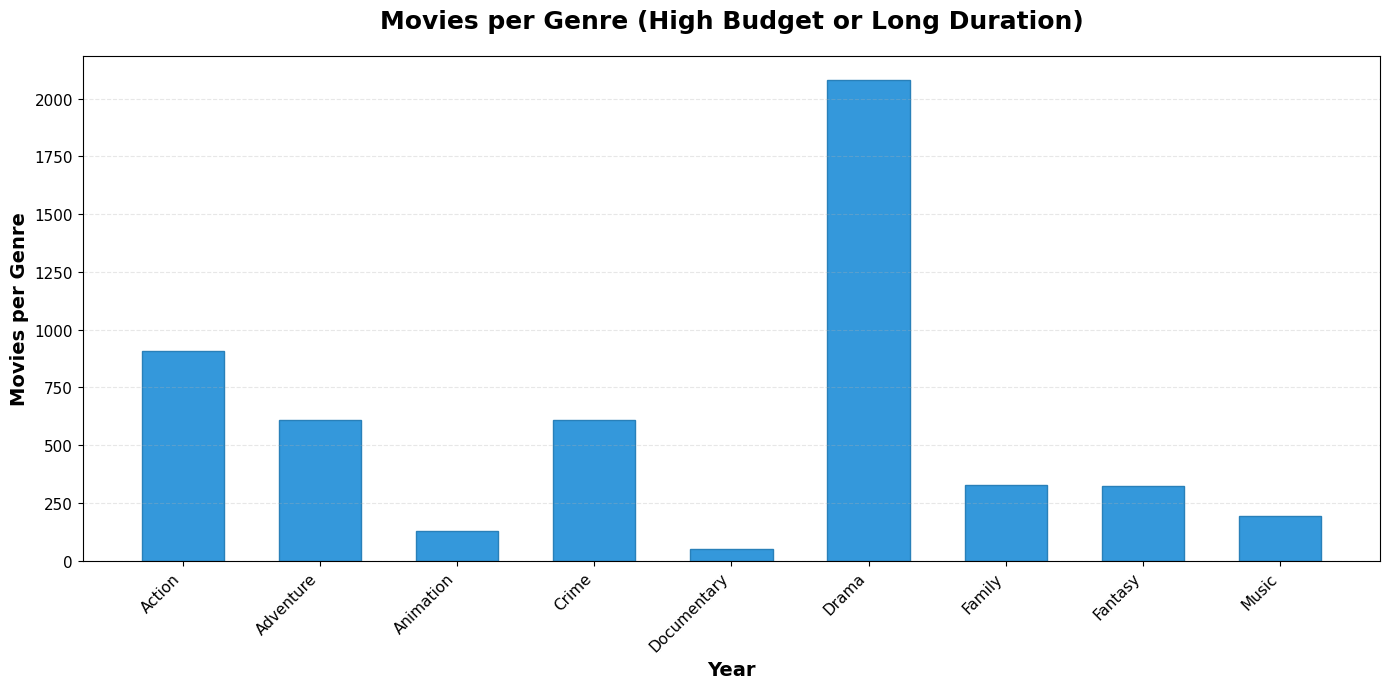

In [155]:
query2 = """
SELECT g.name, COUNT(*) 
FROM movie m JOIN hasGenre hg ON 
m.id = hg.movie_id JOIN genre g ON 
hg.genre_id = g.id 
WHERE m.budget > 1000000 OR m.runtime > 120 GROUP BY g.name
"""
query_graph(query2, cursor, "Movies per Genre (High Budget or Long Duration)", "Year", "Movies per Genre" )

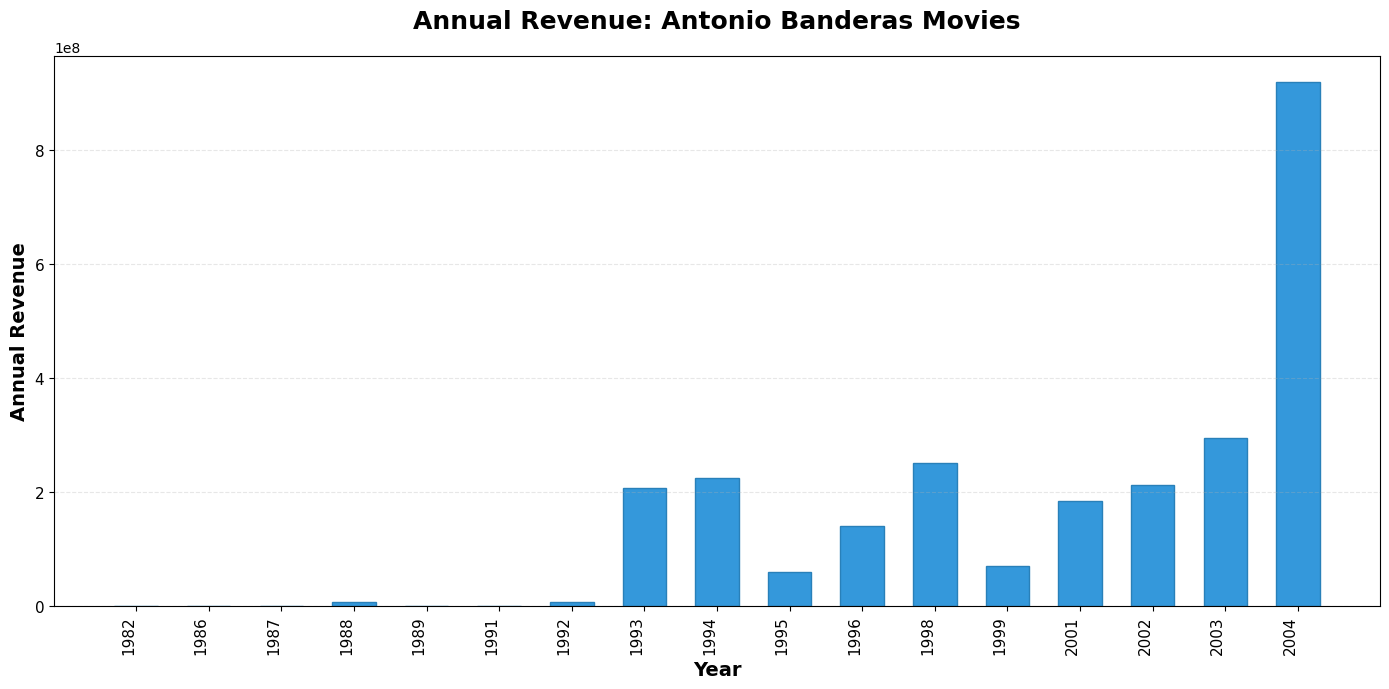

In [156]:
query3 = """
SELECT strftime('%Y', m.release_date) as yr, 
SUM(m.revenue) 
FROM movie m JOIN movie_cast mc ON 
m.id = mc.movie_id 
WHERE mc.name LIKE '%Antonio Banderas%' GROUP BY yr
"""
query_graph(query3, cursor, "Annual Revenue: Antonio Banderas Movies", "Year", "Annual Revenue")

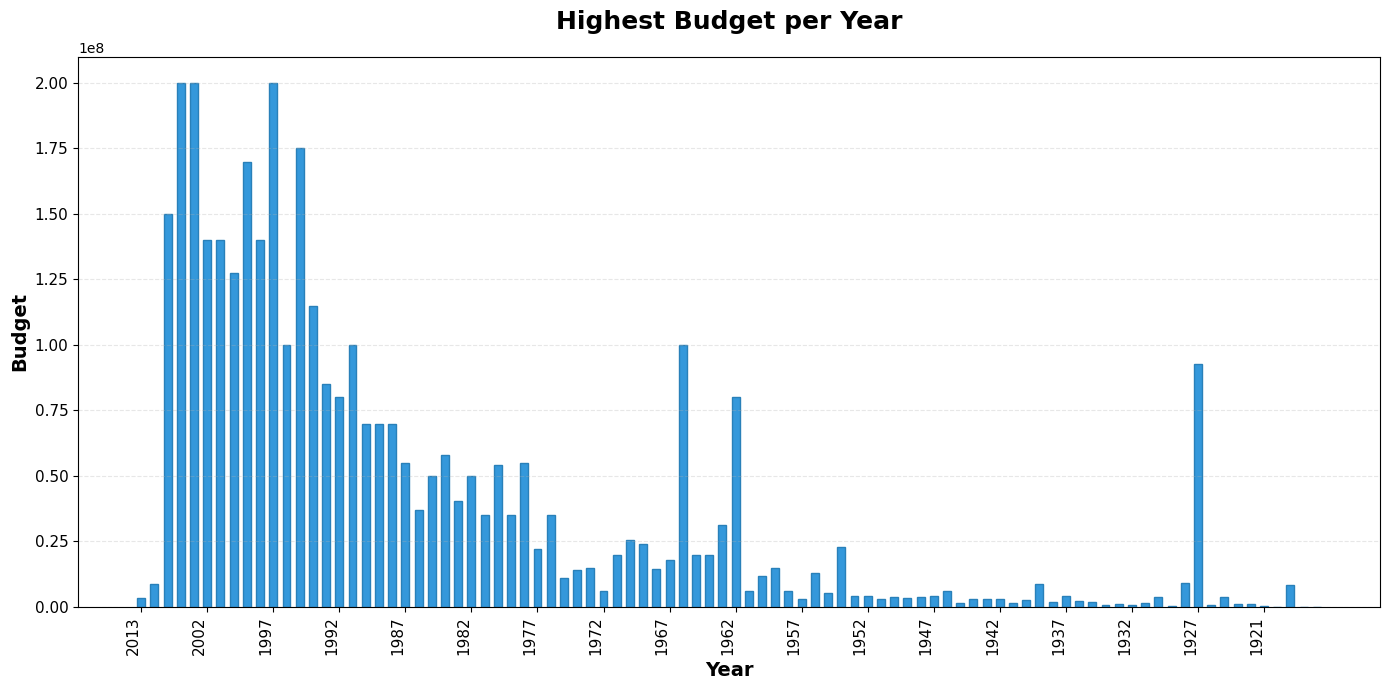

In [157]:
query4 = """
SELECT strftime('%Y', release_date) as yr, 
MAX(budget) FROM movie 
WHERE budget > 0 GROUP BY yr ORDER BY yr DESC
"""
query_graph(query4, cursor, "Highest Budget per Year", "Year", "Budget")

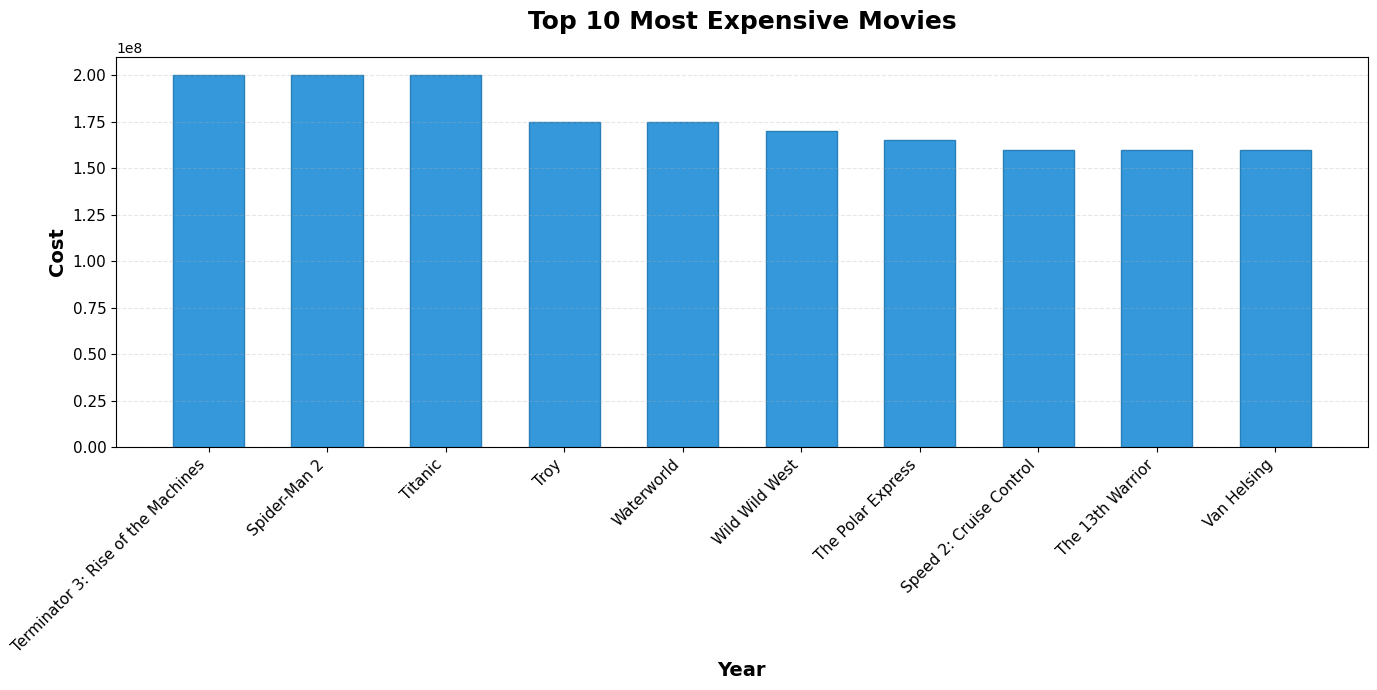

In [158]:
query5 = """
SELECT title, budget 
FROM movie 
ORDER BY budget DESC LIMIT 10
"""
query_graph(query5, cursor, "Top 10 Most Expensive Movies", "Year", "Cost")

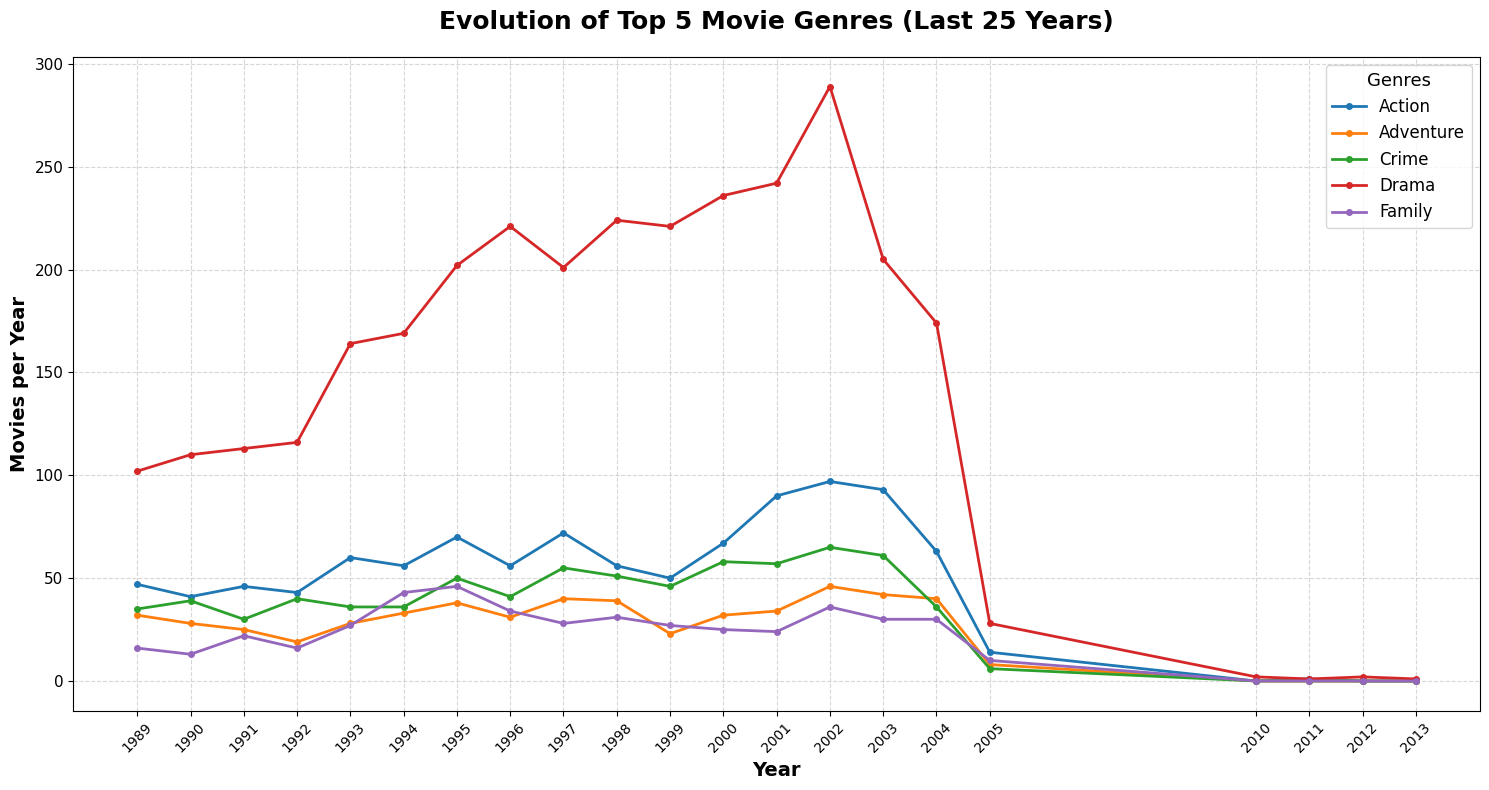

In [159]:
query6 = """
SELECT g.name as genre, strftime('%Y', m.release_date) as year, COUNT(*) as movies_count
FROM movie m
JOIN hasGenre hg ON m.id = hg.movie_id 
JOIN genre g ON hg.genre_id = g.id
WHERE m.release_date IS NOT NULL
GROUP BY genre, year
ORDER BY year ASC;
"""
plot_genre_evolution(query6, cursor)

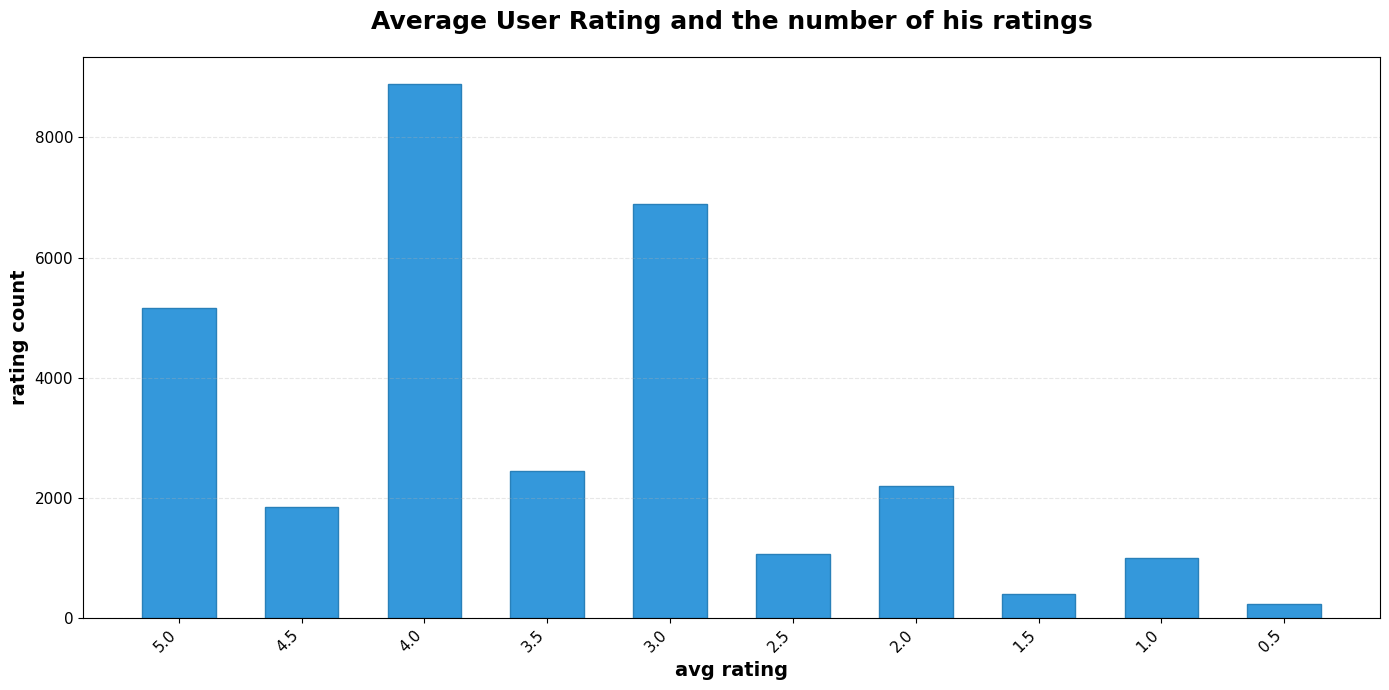

In [160]:
query7 = '''
SELECT rating, COUNT(*) as frequency
FROM ratings
GROUP BY rating
ORDER BY rating DESC;
'''
query_graph(query8, cursor, "Average User Rating and the number of his ratings", "avg rating", "rating count")